Hub Mbank + zmienność

>>> ROZPOCZĘCIE RYGORYSTYCZNEJ WALIDACJI (HYBRYDA: LOKALNY TRENING / FIZYCZNY TEST)
>>> Ostrzeżenie: Po stronie QPU kod będzie czekał na wolne zasoby Odry.


[2016-12-02] LOKALNA Re-optymalizacja wag na oknie treningowym (0 do 52)...
   -> Nowe wagi OOS: q0=0.63, q1=0.10, q2=0.63, q3=0.79
[2016-12-02] Wywoływanie fizycznego QPU dla kroku 52...
   [Hardware] Generowanie 156 obwodów pomiarowych...
   [Hardware] Wysyłanie paczki 1 / 4 do QPU...
   [Hardware] Wysyłanie paczki 2 / 4 do QPU...
   [Hardware] Wysyłanie paczki 3 / 4 do QPU...
   [Hardware] Wysyłanie paczki 4 / 4 do QPU...
   [Hardware] Generowanie 3 obwodów pomiarowych...
   [Hardware] Wysyłanie paczki 1 / 1 do QPU...
[2016-12-09] Wywoływanie fizycznego QPU dla kroku 53...
   [Hardware] Generowanie 156 obwodów pomiarowych...
   [Hardware] Wysyłanie paczki 1 / 4 do QPU...
   [Hardware] Wysyłanie paczki 2 / 4 do QPU...
   [Hardware] Wysyłanie paczki 3 / 4 do QPU...
   [Hardware] Wysyłanie paczki 4 / 4 do QPU...
   [Hardware] Gene

,Accuracy,AUC,Threshold
Quantum SVM (Dynamic Weights),0.5499,0.5170,0.4000
Classical SVM (Raw),0.5519,0.5245,0.4700


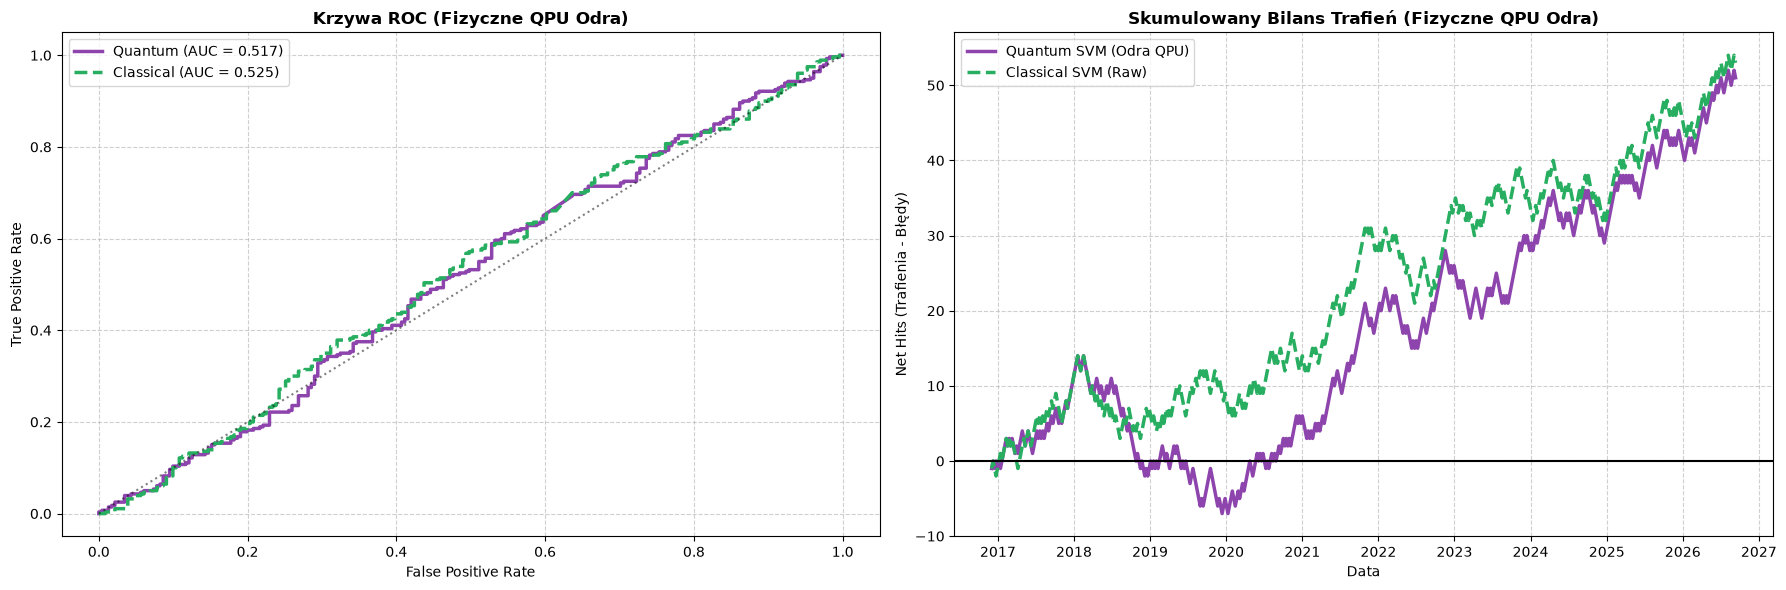

In [1]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution

from qiskit import QuantumCircuit, transpile
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp

# ==========================================
# ODKOMENTUJ DO POŁĄCZENIA Z FIZYCZNĄ ODRĄ:
# from iqm.qiskit import IQMProvider
# from dotenv import load_dotenv
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. PRZYGOTOWANIE BAZY DANYCH (CAUSAL SCALING)
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         # Kubit 0 (Sat)
    'pbv_peo', 'rentownosc_10y',   # Kubit 1 (Sat)
    'pbv_san', 'eurpln',           # Kubit 2 (Sat)
    'pbv_ing', 'wig20',            # Kubit 3 (Sat)
    'pbv_mbk', 'zmiennosc'         # Kubit 4 (NOWY HUB)
]
HUB_QUBIT = 4

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list, valid_indices = [], []

for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    X_norm_list.append(np.clip(current_scaled, 0.0, 2 * np.pi))
    valid_indices.append(t)

X_quantum_base = np.array(X_norm_list)
X_classical_valid = X_raw[valid_indices]
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]

# ==========================================
# 2. SILNIKI KWANTOWE: LOKALNY VS FIZYCZNY
# ==========================================
def build_base_ansatz(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits):
        if i != hub_qubit:
            qc.cx(hub_qubit, i)
    return qc

def build_measurement_circuits(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    # Pomiar w osi X
    qc_x = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): qc_x.h(i)
    qc_x.measure_all()
    
    # Pomiar w osi Y
    qc_y = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): 
        qc_y.sdg(i)
        qc_y.h(i)
    qc_y.measure_all()
    
    # Pomiar w osi Z
    qc_z = build_base_ansatz(x, num_qubits, hub_qubit)
    qc_z.measure_all()
    
    return qc_x, qc_y, qc_z

def expectation_from_counts(counts, num_qubits):
    total_shots = sum(counts.values())
    expvals = np.zeros(num_qubits)
    for bitstring, count in counts.items():
        bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
        for q in range(num_qubits): expvals[q] += bits[q] * count
    return expvals / total_shots

# SILNIK LOKALNY (SZYBKI) - Używany TYLKO do optymalizacji wag
def get_fast_sim_projections(X_q, num_qubits=5):
    estimator = StatevectorEstimator()
    observables = [SparsePauliOp("".join(['I' if j != q else p for j in reversed(range(num_qubits))])) 
                   for q in range(num_qubits) for p in ['X', 'Y', 'Z']]
    Phi = np.zeros((len(X_q), num_qubits * 3))
    
    circuits = [build_base_ansatz(x, num_qubits, HUB_QUBIT) for x in X_q]
    job = estimator.run([(circ, observables) for circ in circuits])
    
    for i, res in enumerate(job.result()):
        Phi[i] = res.data.evs
    return Phi

# SILNIK FIZYCZNY (BLOKUJĄCY) - Ręczne pomiary odporne na brak BackendEstimatora
def get_physical_qpu_projections(X_q, num_qubits=5):
    # ==========================================
    # W TYM MIEJSCU ODKOMENTUJ PODŁĄCZENIE ODRY:
    # load_dotenv("token.env")
    # provider = IQMProvider(os.getenv("SERVER"), token=os.getenv("TOKEN"))
    # backend = provider.get_backend("Odra") # Lub inna nazwa sprzętu
    # ==========================================
    
    # SYMULATOR ZASTĘPCZY (usuń to, gdy podłączysz Odrę)
    from qiskit_aer import AerSimulator
    backend = AerSimulator()
    
    print(f"   [Hardware] Generowanie {len(X_q) * 3} obwodów pomiarowych...")
    all_circuits = []
    for x in X_q: 
        all_circuits.extend(build_measurement_circuits(x, num_qubits, HUB_QUBIT))
    
    transpiled = transpile(all_circuits, backend=backend, optimization_level=3)
    
    shots = 4000
    batch_size = 50 # Paczkowanie, żeby nie zapchać serwera API
    all_counts = []
    
    for i in range(0, len(transpiled), batch_size):
        batch = transpiled[i : i + batch_size]
        print(f"   [Hardware] Wysyłanie paczki {i//batch_size + 1} / {(len(transpiled)-1)//batch_size + 1} do QPU...")
        
        # BLOKADA: Skrypt czeka tutaj na sprzęt
        job = backend.run(batch, shots=shots)
        
        for j in range(len(batch)): 
            all_counts.append(job.result().get_counts(j))
            
    Phi_qpu = np.zeros((len(X_q), num_qubits * 3))
    for i in range(len(X_q)):
        for q in range(num_qubits):
            Phi_qpu[i, 3 * q + 0] = expectation_from_counts(all_counts[3 * i], num_qubits)[q]
            Phi_qpu[i, 3 * q + 1] = expectation_from_counts(all_counts[3 * i + 1], num_qubits)[q]
            Phi_qpu[i, 3 * q + 2] = expectation_from_counts(all_counts[3 * i + 2], num_qubits)[q]
            
    return Phi_qpu

# ==========================================
# 3. ZAGNIEŻDŻONA OPTYMALIZACJA WAG (STRICT IN-SAMPLE)
# ==========================================
def optimize_weights_for_window(X_train_raw, y_train_raw):
    """Optymalizuje wagi TYLKO na symulatorze (get_fast_sim_projections), żeby nie czekać latami."""
    
    def objective_function(weights):
        w_map = {0: weights[0], 1: weights[1], 2: weights[2], 3: weights[3], 4: 1.0}
        feature_multipliers = np.zeros(10)
        for q in range(5):
            feature_multipliers[2*q] = w_map[q]; feature_multipliers[2*q + 1] = w_map[q]
            
        X_weighted = X_train_raw * feature_multipliers
        Phi_sim = get_fast_sim_projections(X_weighted) 
        
        inner_cv = TimeSeriesSplit(n_splits=3)
        pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True))])
        
        try:
            search = GridSearchCV(pipeline, {"svm__C": [0.1, 1.0, 5.0], "svm__gamma": ["scale"]}, 
                                  cv=inner_cv, scoring="roc_auc", n_jobs=-1).fit(Phi_sim, y_train_raw)
            return -search.best_score_  
        except:
            return 0.0

    bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]
    result = differential_evolution(objective_function, bounds, maxiter=3, popsize=3, seed=42)
    return result.x

# ==========================================
# 4. GŁÓWNA PĘTLA WALK-FORWARD (OUT-OF-SAMPLE - FIZYCZNA ODRA)
# ==========================================
print(">>> ROZPOCZĘCIE RYGORYSTYCZNEJ WALIDACJI (HYBRYDA: LOKALNY TRENING / FIZYCZNY TEST)")
print(">>> Ostrzeżenie: Po stronie QPU kod będzie czekał na wolne zasoby Odry.\n")

TRAIN_WINDOW = 52
REOPTIMIZE_EVERY = 26  

current_weights = np.array([1.0, 1.0, 1.0, 1.0]) 
results_qpu = {"probs": [], "preds": []}
results_cls = {"probs": [], "preds": []}
y_true_final = []
dates_final = []

pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True))])
inner_cv = TimeSeriesSplit(n_splits=3)
param_grid = {"svm__C": [0.1, 1.0, 5.0, 10.0], "svm__gamma": ["scale", "auto"]}

for t in range(TRAIN_WINDOW, len(y)):
    if (t - TRAIN_WINDOW) % REOPTIMIZE_EVERY == 0:
        print(f"\n[{pd.Timestamp(dates[t]).date()}] LOKALNA Re-optymalizacja wag na oknie treningowym ({t-TRAIN_WINDOW} do {t})...")
        current_weights = optimize_weights_for_window(X_quantum_base[t - TRAIN_WINDOW : t], y[t - TRAIN_WINDOW : t])
        print(f"   -> Nowe wagi OOS: q0={current_weights[0]:.2f}, q1={current_weights[1]:.2f}, q2={current_weights[2]:.2f}, q3={current_weights[3]:.2f}")

    w_map = {0: current_weights[0], 1: current_weights[1], 2: current_weights[2], 3: current_weights[3], 4: 1.0}
    multipliers = np.zeros(10)
    for q in range(5): multipliers[2*q] = w_map[q]; multipliers[2*q+1] = w_map[q]
    
    X_quantum_tr = X_quantum_base[t - TRAIN_WINDOW : t] * multipliers
    X_quantum_te = X_quantum_base[t : t + 1] * multipliers
    
    # ---------------------------------------------------------
    # WYMUSZENIE WYLICZEŃ FIZYCZNYCH (BLOKADA WYKONANIA)
    # ---------------------------------------------------------
    print(f"[{pd.Timestamp(dates[t]).date()}] Wywoływanie fizycznego QPU dla kroku {t}...")
    Phi_tr = get_physical_qpu_projections(X_quantum_tr)
    Phi_te = get_physical_qpu_projections(X_quantum_te)
    
    X_cls_tr = X_classical_valid[t - TRAIN_WINDOW : t]
    X_cls_te = X_classical_valid[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    y_true_final.append(y[t])
    dates_final.append(dates[t])
    
    # Trening i Predykcja
    search_qpu = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1).fit(Phi_tr, y_tr)
    results_qpu["probs"].append(search_qpu.predict_proba(Phi_te)[0, 1])
    
    search_cls = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1).fit(X_cls_tr, y_tr)
    results_cls["probs"].append(search_cls.predict_proba(X_cls_te)[0, 1])

y_true_final = np.array(y_true_final)

# Znajdowanie optymalnego progu
def get_best_preds(probs, y_true):
    probs = np.array(probs)
    best_thresh, best_acc = 0.50, 0
    for thresh in np.arange(0.40, 0.60, 0.01):
        acc = accuracy_score(y_true, (probs > thresh).astype(int))
        if acc > best_acc: best_acc, best_thresh = acc, thresh
    return (probs > best_thresh).astype(int), best_thresh

results_qpu["preds"], qpu_thresh = get_best_preds(results_qpu["probs"], y_true_final)
results_cls["preds"], cls_thresh = get_best_preds(results_cls["probs"], y_true_final)

# ==========================================
# 5. OSTATECZNE PODSUMOWANIE (UCZCIWE WYNIKI)
# ==========================================
df_metrics = pd.DataFrame(index=["Quantum SVM (Dynamic Weights)", "Classical SVM (Raw)"], columns=["Accuracy", "AUC", "Threshold"])
df_metrics.loc["Quantum SVM (Dynamic Weights)"] = [accuracy_score(y_true_final, results_qpu["preds"]), roc_auc_score(y_true_final, results_qpu["probs"]), qpu_thresh]
df_metrics.loc["Classical SVM (Raw)"] = [accuracy_score(y_true_final, results_cls["preds"]), roc_auc_score(y_true_final, results_cls["probs"]), cls_thresh]

print("\n--- UCZCIWE PORÓWNANIE MODELI OOS (QPU ODRA) ---")
display(df_metrics.style.format("{:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

fpr_qpu, tpr_qpu, _ = roc_curve(y_true_final, results_qpu["probs"])
fpr_cls, tpr_cls, _ = roc_curve(y_true_final, results_cls["probs"])

ax[0].plot(fpr_qpu, tpr_qpu, color="#8e44ad", lw=2.5, label=f'Quantum (AUC = {df_metrics.loc["Quantum SVM (Dynamic Weights)", "AUC"]:.3f})')
ax[0].plot(fpr_cls, tpr_cls, color="#27ae60", lw=2.5, ls="--", label=f'Classical (AUC = {df_metrics.loc["Classical SVM (Raw)", "AUC"]:.3f})')
ax[0].plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax[0].set_title('Krzywa ROC (Fizyczne QPU Odra)', fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

net_hits_qpu = np.cumsum(np.where(results_qpu["preds"] == y_true_final, 1, -1))
net_hits_cls = np.cumsum(np.where(results_cls["preds"] == y_true_final, 1, -1))

ax[1].plot(dates_final, net_hits_qpu, color="#8e44ad", lw=2.5, label="Quantum SVM (Odra QPU)")
ax[1].plot(dates_final, net_hits_cls, color="#27ae60", lw=2.5, ls="--", label="Classical SVM (Raw)")
ax[1].axhline(0, color='black', lw=1.5)
ax[1].set_title('Skumulowany Bilans Trafień (Fizyczne QPU Odra)', fontweight='bold')
ax[1].set_xlabel('Data')
ax[1].set_ylabel('Net Hits (Trafienia - Błędy)')
ax[1].legend(loc='upper left')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Hub PKO + Wibor

In [ ]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution

from qiskit import QuantumCircuit, transpile
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp

# ==========================================
# ODKOMENTUJ DO POŁĄCZENIA Z FIZYCZNĄ ODRĄ:
# from iqm.qiskit import IQMProvider
# from dotenv import load_dotenv
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. PRZYGOTOWANIE BAZY DANYCH (CAUSAL SCALING)
# ==========================================
csv_path = "dataset_final.csv" if os.path.exists("dataset_final.csv") else "dane/dataset_final.csv"

FEATURES_MAP = [
    'pbv_pko', 'wibor_3m',         # Kubit 0 (NOWY HUB)
    'pbv_peo', 'rentownosc_10y',   # Kubit 1 (Sat)
    'pbv_san', 'eurpln',           # Kubit 2 (Sat)
    'pbv_ing', 'wig20',            # Kubit 3 (Sat)
    'pbv_mbk', 'zmiennosc'         # Kubit 4 (Sat)
]
HUB_QUBIT = 0

df = pd.read_csv(csv_path, index_col=0)
df.index = pd.to_datetime(df.index)
X_raw = df[FEATURES_MAP].values
y_raw = df["target_y"].astype(int).values
dates_raw = df.index.values

LOOKBACK = 52
X_norm_list, valid_indices = [], []

for t in range(LOOKBACK, len(X_raw)):
    past_window = X_raw[t - LOOKBACK : t]
    min_vals = past_window.min(axis=0)
    max_vals = past_window.max(axis=0)
    range_vals = np.where((max_vals - min_vals) == 0, 1e-8, max_vals - min_vals)
    current_scaled = ((X_raw[t] - min_vals) / range_vals) * (2 * np.pi)
    X_norm_list.append(np.clip(current_scaled, 0.0, 2 * np.pi))
    valid_indices.append(t)

X_quantum_base = np.array(X_norm_list)
X_classical_valid = X_raw[valid_indices]
y = y_raw[valid_indices]
dates = dates_raw[valid_indices]

# ==========================================
# 2. SILNIKI KWANTOWE: LOKALNY VS FIZYCZNY
# ==========================================
def build_base_ansatz(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        qc.ry(x[2 * i], i)
        qc.rz(x[2 * i + 1], i)
    for i in range(num_qubits):
        if i != hub_qubit:
            qc.cx(hub_qubit, i)
    return qc

def build_measurement_circuits(x, num_qubits=5, hub_qubit=HUB_QUBIT):
    # Pomiar w osi X
    qc_x = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): qc_x.h(i)
    qc_x.measure_all()
    
    # Pomiar w osi Y
    qc_y = build_base_ansatz(x, num_qubits, hub_qubit)
    for i in range(num_qubits): 
        qc_y.sdg(i)
        qc_y.h(i)
    qc_y.measure_all()
    
    # Pomiar w osi Z
    qc_z = build_base_ansatz(x, num_qubits, hub_qubit)
    qc_z.measure_all()
    
    return qc_x, qc_y, qc_z

def expectation_from_counts(counts, num_qubits):
    total_shots = sum(counts.values())
    expvals = np.zeros(num_qubits)
    for bitstring, count in counts.items():
        bits = [1 if b == '0' else -1 for b in reversed(bitstring.replace(" ", ""))]
        for q in range(num_qubits): expvals[q] += bits[q] * count
    return expvals / total_shots

# SILNIK LOKALNY (SZYBKI) - Używany TYLKO do optymalizacji wag
def get_fast_sim_projections(X_q, num_qubits=5):
    estimator = StatevectorEstimator()
    observables = [SparsePauliOp("".join(['I' if j != q else p for j in reversed(range(num_qubits))])) 
                   for q in range(num_qubits) for p in ['X', 'Y', 'Z']]
    Phi = np.zeros((len(X_q), num_qubits * 3))
    
    circuits = [build_base_ansatz(x, num_qubits, HUB_QUBIT) for x in X_q]
    job = estimator.run([(circ, observables) for circ in circuits])
    
    for i, res in enumerate(job.result()):
        Phi[i] = res.data.evs
    return Phi

# SILNIK FIZYCZNY (BLOKUJĄCY) - Ręczne pomiary odporne na brak BackendEstimatora
def get_physical_qpu_projections(X_q, num_qubits=5):
    # ==========================================
    # W TYM MIEJSCU ODKOMENTUJ PODŁĄCZENIE ODRY:
    # load_dotenv("token.env")
    # provider = IQMProvider(os.getenv("SERVER"), token=os.getenv("TOKEN"))
    # backend = provider.get_backend("Odra") # Lub inna nazwa sprzętu
    # ==========================================
    
    # SYMULATOR ZASTĘPCZY (usuń to, gdy podłączysz Odrę)
    from qiskit_aer import AerSimulator
    backend = AerSimulator()
    
    print(f"   [Hardware] Generowanie {len(X_q) * 3} obwodów pomiarowych...")
    all_circuits = []
    for x in X_q: 
        all_circuits.extend(build_measurement_circuits(x, num_qubits, HUB_QUBIT))
    
    transpiled = transpile(all_circuits, backend=backend, optimization_level=3)
    
    shots = 4000
    batch_size = 50 # Paczkowanie, żeby nie zapchać serwera API
    all_counts = []
    
    for i in range(0, len(transpiled), batch_size):
        batch = transpiled[i : i + batch_size]
        print(f"   [Hardware] Wysyłanie paczki {i//batch_size + 1} / {(len(transpiled)-1)//batch_size + 1} do QPU...")
        
        # BLOKADA: Skrypt czeka tutaj na sprzęt
        job = backend.run(batch, shots=shots)
        
        for j in range(len(batch)): 
            all_counts.append(job.result().get_counts(j))
            
    Phi_qpu = np.zeros((len(X_q), num_qubits * 3))
    for i in range(len(X_q)):
        for q in range(num_qubits):
            Phi_qpu[i, 3 * q + 0] = expectation_from_counts(all_counts[3 * i], num_qubits)[q]
            Phi_qpu[i, 3 * q + 1] = expectation_from_counts(all_counts[3 * i + 1], num_qubits)[q]
            Phi_qpu[i, 3 * q + 2] = expectation_from_counts(all_counts[3 * i + 2], num_qubits)[q]
            
    return Phi_qpu

# ==========================================
# 3. ZAGNIEŻDŻONA OPTYMALIZACJA WAG (STRICT IN-SAMPLE)
# ==========================================
def optimize_weights_for_window(X_train_raw, y_train_raw):
    """Optymalizuje wagi TYLKO na symulatorze (get_fast_sim_projections), żeby nie czekać latami."""
    
    def objective_function(weights):
        w_map = {0: weights[0], 1: weights[1], 2: weights[2], 3: weights[3], 4: 1.0}
        feature_multipliers = np.zeros(10)
        for q in range(5):
            feature_multipliers[2*q] = w_map[q]; feature_multipliers[2*q + 1] = w_map[q]
            
        X_weighted = X_train_raw * feature_multipliers
        Phi_sim = get_fast_sim_projections(X_weighted) 
        
        inner_cv = TimeSeriesSplit(n_splits=3)
        pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True))])
        
        try:
            search = GridSearchCV(pipeline, {"svm__C": [0.1, 1.0, 5.0], "svm__gamma": ["scale"]}, 
                                  cv=inner_cv, scoring="roc_auc", n_jobs=-1).fit(Phi_sim, y_train_raw)
            return -search.best_score_  
        except:
            return 0.0

    bounds = [(0.0, 1.0), (0.0, 1.0), (0.0, 1.0), (0.0, 1.0)]
    result = differential_evolution(objective_function, bounds, maxiter=3, popsize=3, seed=42)
    return result.x

# ==========================================
# 4. GŁÓWNA PĘTLA WALK-FORWARD (OUT-OF-SAMPLE - FIZYCZNA ODRA)
# ==========================================
print(">>> ROZPOCZĘCIE RYGORYSTYCZNEJ WALIDACJI (HYBRYDA: LOKALNY TRENING / FIZYCZNY TEST)")
print(">>> Ostrzeżenie: Po stronie QPU kod będzie czekał na wolne zasoby Odry.\n")

TRAIN_WINDOW = 52
REOPTIMIZE_EVERY = 26  

current_weights = np.array([1.0, 1.0, 1.0, 1.0]) 
results_qpu = {"probs": [], "preds": []}
results_cls = {"probs": [], "preds": []}
y_true_final = []
dates_final = []

pipeline = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf", probability=True))])
inner_cv = TimeSeriesSplit(n_splits=3)
param_grid = {"svm__C": [0.1, 1.0, 5.0, 10.0], "svm__gamma": ["scale", "auto"]}

for t in range(TRAIN_WINDOW, len(y)):
    if (t - TRAIN_WINDOW) % REOPTIMIZE_EVERY == 0:
        print(f"\n[{pd.Timestamp(dates[t]).date()}] LOKALNA Re-optymalizacja wag na oknie treningowym ({t-TRAIN_WINDOW} do {t})...")
        current_weights = optimize_weights_for_window(X_quantum_base[t - TRAIN_WINDOW : t], y[t - TRAIN_WINDOW : t])
        print(f"   -> Nowe wagi OOS: q0={current_weights[0]:.2f}, q1={current_weights[1]:.2f}, q2={current_weights[2]:.2f}, q3={current_weights[3]:.2f}")

    w_map = {0: current_weights[0], 1: current_weights[1], 2: current_weights[2], 3: current_weights[3], 4: 1.0}
    multipliers = np.zeros(10)
    for q in range(5): multipliers[2*q] = w_map[q]; multipliers[2*q+1] = w_map[q]
    
    X_quantum_tr = X_quantum_base[t - TRAIN_WINDOW : t] * multipliers
    X_quantum_te = X_quantum_base[t : t + 1] * multipliers
    
    # ---------------------------------------------------------
    # WYMUSZENIE WYLICZEŃ FIZYCZNYCH (BLOKADA WYKONANIA)
    # ---------------------------------------------------------
    print(f"[{pd.Timestamp(dates[t]).date()}] Wywoływanie fizycznego QPU dla kroku {t}...")
    Phi_tr = get_physical_qpu_projections(X_quantum_tr)
    Phi_te = get_physical_qpu_projections(X_quantum_te)
    
    X_cls_tr = X_classical_valid[t - TRAIN_WINDOW : t]
    X_cls_te = X_classical_valid[t : t + 1]
    y_tr = y[t - TRAIN_WINDOW : t]
    
    y_true_final.append(y[t])
    dates_final.append(dates[t])
    
    # Trening i Predykcja
    search_qpu = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1).fit(Phi_tr, y_tr)
    results_qpu["probs"].append(search_qpu.predict_proba(Phi_te)[0, 1])
    
    search_cls = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1).fit(X_cls_tr, y_tr)
    results_cls["probs"].append(search_cls.predict_proba(X_cls_te)[0, 1])

y_true_final = np.array(y_true_final)

# Znajdowanie optymalnego progu
def get_best_preds(probs, y_true):
    probs = np.array(probs)
    best_thresh, best_acc = 0.50, 0
    for thresh in np.arange(0.40, 0.60, 0.01):
        acc = accuracy_score(y_true, (probs > thresh).astype(int))
        if acc > best_acc: best_acc, best_thresh = acc, thresh
    return (probs > best_thresh).astype(int), best_thresh

results_qpu["preds"], qpu_thresh = get_best_preds(results_qpu["probs"], y_true_final)
results_cls["preds"], cls_thresh = get_best_preds(results_cls["probs"], y_true_final)

# ==========================================
# 5. OSTATECZNE PODSUMOWANIE (UCZCIWE WYNIKI)
# ==========================================
df_metrics = pd.DataFrame(index=["Quantum SVM (Dynamic Weights)", "Classical SVM (Raw)"], columns=["Accuracy", "AUC", "Threshold"])
df_metrics.loc["Quantum SVM (Dynamic Weights)"] = [accuracy_score(y_true_final, results_qpu["preds"]), roc_auc_score(y_true_final, results_qpu["probs"]), qpu_thresh]
df_metrics.loc["Classical SVM (Raw)"] = [accuracy_score(y_true_final, results_cls["preds"]), roc_auc_score(y_true_final, results_cls["probs"]), cls_thresh]

print("\n--- UCZCIWE PORÓWNANIE MODELI OOS (QPU ODRA) ---")
display(df_metrics.style.format("{:.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

fpr_qpu, tpr_qpu, _ = roc_curve(y_true_final, results_qpu["probs"])
fpr_cls, tpr_cls, _ = roc_curve(y_true_final, results_cls["probs"])

ax[0].plot(fpr_qpu, tpr_qpu, color="#8e44ad", lw=2.5, label=f'Quantum (AUC = {df_metrics.loc["Quantum SVM (Dynamic Weights)", "AUC"]:.3f})')
ax[0].plot(fpr_cls, tpr_cls, color="#27ae60", lw=2.5, ls="--", label=f'Classical (AUC = {df_metrics.loc["Classical SVM (Raw)", "AUC"]:.3f})')
ax[0].plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax[0].set_title('Krzywa ROC (Fizyczne QPU Odra)', fontweight='bold')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

net_hits_qpu = np.cumsum(np.where(results_qpu["preds"] == y_true_final, 1, -1))
net_hits_cls = np.cumsum(np.where(results_cls["preds"] == y_true_final, 1, -1))

ax[1].plot(dates_final, net_hits_qpu, color="#8e44ad", lw=2.5, label="Quantum SVM (Odra QPU)")
ax[1].plot(dates_final, net_hits_cls, color="#27ae60", lw=2.5, ls="--", label="Classical SVM (Raw)")
ax[1].axhline(0, color='black', lw=1.5)
ax[1].set_title('Skumulowany Bilans Trafień (Fizyczne QPU Odra)', fontweight='bold')
ax[1].set_xlabel('Data')
ax[1].set_ylabel('Net Hits (Trafienia - Błędy)')
ax[1].legend(loc='upper left')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()